# 👁️ The Power of Convolutional Neural Networks (CNNs)

Welcome to the engine of modern Computer Vision.

In previous lessons, we learned that standard Multi-Layer Perceptrons (MLPs) struggle when objects move around in an image. They memorize exact pixel locations. To fix this, we need a network that looks at **patterns** (edges, textures, shapes) regardless of where they are.

Enter the **Convolutional Neural Network (CNN)**.

### What we will explore today:
1.  **Visualizing Kernels:** How a sliding window extracts features.
2.  **Volume & Depth:** How networks grow "deep" (e.g., $600\times450\times3 \rightarrow 200\times150\times10$).
3.  **AlexNet & The Deep Learning Revolution:** Why 2012 changed everything.
4.  **The PyTorch CNN Toolbox:** Essential functions you need to know.
5.  **The CIFAR-10 Championship:** Build your own CNN and beat the Translation Stress Test!

## 1. How Kernels and Filters Work 🔍

Instead of looking at the whole image at once, a CNN looks at a small patch (e.g., $3 \times 3$ pixels) using a **Kernel** (or Filter). 
This kernel slides across the image. At each step, it multiplies its weights with the image pixels and sums them up to create a new pixel in a **Feature Map**.

Look at the animation below. The yellow $3 \times 3$ kernel slides over the green image to produce the red feature map.

![Convolution Animation](https://cdn-media-1.freecodecamp.org/images/gb08-2i83P5wPzs3SL-vosNb6Iur5kb5ZH43)

Different kernels detect different things: one might detect vertical edges, another might detect horizontal edges, and another might detect color blobs.

In [2]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID" # Ensures IDs match nvidia-smi
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2"

In [3]:
import torch
print(torch.cuda.current_device())
print(torch.cuda.get_device_name(0))

0
NVIDIA GeForce RTX 2080 Ti


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision.models import alexnet
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from PIL import Image
import os
import glob
from datetime import datetime
from tqdm.notebook import tqdm
from IPython.display import display

# Setup visualization settings
plt.rcParams['figure.figsize'] = (12, 6)
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Ready to explore Convolutions on device: {device}")

✅ Ready to explore Convolutions on device: cuda


## 2. Dimensionality: How does $600\times450\times3$ become $200\times150\times10$? 📦

A very common question when building CNNs is: *"I fed an image of size 600x450 with 3 RGB channels into a layer. How did it output a tensor of size 200x150x10?"*

Let's break it down into two parts: **Spatial Shrinking** and **Depth Growing**.

### Part A: Why does it shrink spatially? ($600 \times 450 \rightarrow 200 \times 150$)
This happens because of **Stride** or **Pooling**. 
* **Stride** is the step size of our sliding window. 
* If we set `stride=3`, the sliding window takes large steps, skipping 3 pixels at a time. 
* Math: $600 / 3 = 200$ and $450 / 3 = 150$.

### Part B: Why does the depth grow? ($3 \text{ Channels} \rightarrow 10 \text{ Channels}$)
This is the magic of CNNs. We do **not** use just one filter. We use **many different filters** at the same time in a single layer!
* Filter 1 might look for **Horizontal Edges**.
* Filter 2 might look for **Vertical Edges**.
* Filter 3 might look for **Red Spots**.

Each filter scans the entire input and produces **ONE** 2D Feature Map. 
If we specify `out_channels=10`, PyTorch creates **10 different filters**. We get 10 Feature Maps and stack them together like slices of bread, creating a depth of 10.

Let's prove this with code:

In [5]:
# 1. Create a dummy High-Res Image: [Batch=1, Channels=3, Height=600, Width=450]
big_image = torch.randn(1, 3, 600, 450)
print(f"Input shape:  {big_image.shape}")

# 2. Create a Conv2d Layer
# in_channels = 3 (RGB)
# out_channels = 10 (We are telling PyTorch to learn 10 DIFFERENT filters!)
# kernel_size = 3 (Each filter is 3x3)
# stride = 3 (This shrinks the spatial height and width by a factor of 3)
conv_layer = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3, stride=3, padding=1)

# 3. Pass image through layer
big_output = conv_layer(big_image)
print(f"Output shape: {big_output.shape}")
print("Notice how Channels became 10, and Height/Width shrank!")

Input shape:  torch.Size([1, 3, 600, 450])
Output shape: torch.Size([1, 10, 200, 150])
Notice how Channels became 10, and Height/Width shrank!


## 3. AlexNet & The Deep Learning Revolution 🚀

In 2012, a network called **AlexNet** (created by Alex Krizhevsky) absolutely destroyed the competition in the ImageNet challenge (a massive visual recognition dataset). It sparked the modern Deep Learning revolution. 

**Why was AlexNet such a breakthrough?**
1. **ReLU Activations:** Before AlexNet, scientists used `Sigmoid` or `Tanh`. AlexNet used `ReLU` (Rectified Linear Unit). This fixed the vanishing gradient problem and made training deep networks much faster.
2. **Overlapping Max Pooling:** It used pooling layers to shrink the image representation. This helped the network focus on the *presence* of features rather than their exact pixel-perfect locations.
3. **Dropout:** It introduced Dropout to randomly turn off neurons during training, preventing the network from memorizing the data (overfitting).
4. **GPU Training:** It was one of the first models heavily optimized to train on Nvidia GPUs (GTX 580), reducing training time from months to days.

## 4. The PyTorch CNN Toolbox 🛠️

To build CNNs like AlexNet, you need to know the basic PyTorch building blocks. Here are the most important functions you will use:

1. `nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)`
   * The workhorse. This is the layer that actually learns the filters.

2. `nn.MaxPool2d(kernel_size, stride)`
   * Acts like a magnifying glass zooming out. If you have a $2 \times 2$ window, it just takes the MAXIMUM number in that window and discards the rest. 
   * **Crucial:** This makes the network **Translation Invariant** (it doesn't care if an eye is shifted 1 pixel to the left or right).

3. `nn.BatchNorm2d(num_features)`
   * Normalizes the feature maps to prevent numbers from exploding during training. Usually placed right after Convolution and before ReLU.

4. `nn.Flatten()`
   * Flattens a 3D volume (Channels $\times$ Height $\times$ Width) into a 1D vector so it can be passed into standard Linear layers at the end of the network.
   
5. `nn.Dropout(p=0.5)`
   * Regularization. Randomly zeroes out entire channels or neurons to force the network to learn robust features.

## 🏆 Part 5: The Neural Network Championship (Oxford-Pets Dataset)

It is time for revenge! In previous lessons, our MLPs failed the **Corner Stress Test** because they memorized pixel locations. 
Now, we will unleash Convolutional Neural Networks on the **COxford-Pets** dataset.

### The Task:
Classify RGB images into  categories. 

### The Rules:
1. Use `nn.Conv2d` and `nn.MaxPool2d` to build your feature extractors.
2. Flatten the output, and use `nn.Linear` at the very end to output classes.
3. See if your CNN can survive the Corner Stress Test!

In [43]:
# --- CUSTOM DATASET CLASS ---
class OxfordPetsDataset(torch.utils.data.Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        
        # Find all jpg images
        self.image_paths = glob.glob(os.path.join(img_dir, "*.jpg"))
        
        # Extract classes from filenames (Format: Breed_Name_ID.jpg)
        self.labels = []
        classes_set = set()
        for path in self.image_paths:
            filename = os.path.basename(path)
            class_name = "_".join(filename.split("_")[:-1])
            classes_set.add(class_name)
            
        self.unique_classes = sorted(list(classes_set))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.unique_classes)}
        self.num_classes = len(self.unique_classes)
        
    def __len__(self):
        return len(self.image_paths)
        
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        # Convert to RGB (some pet images are RGBA or Grayscale)
        image = Image.open(img_path).convert("RGB")
        
        filename = os.path.basename(img_path)
        class_name = "_".join(filename.split("_")[:-1])
        label = self.class_to_idx[class_name]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# --- LOAD AND SPLIT DATA ---
DATASET_PATH = r"../Datasets/oxford-iiit-pet/images"

transform = transforms.Compose([
    transforms.Resize((224, 224)), # AlexNet standard size
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

print("⏳ Loading Oxford-IIIT Pet Dataset...")
try:
    full_dataset = OxfordPetsDataset(img_dir=DATASET_PATH, transform=transform)
    print(f"Found {len(full_dataset)} images belonging to {full_dataset.num_classes} classes.")
    
    # Split 80% Train, 10% Val, 10% Test
    train_sz = int(0.8 * len(full_dataset))
    val_sz = int(0.1 * len(full_dataset))
    test_sz = len(full_dataset) - train_sz - val_sz
    
    train_set, val_set, test_set = torch.utils.data.random_split(full_dataset, [train_sz, val_sz, test_sz])
    
    BATCH_SIZE = 32
    train_loader = torch.utils.data.DataLoader(
    train_set, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=32,     # Uses 8 CPU cores to prepare images in parallel
    pin_memory=True     # Speeds up the transfer from CPU RAM to GPU VRAM
    )
    
    val_loader = torch.utils.data.DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)
    print("✅ Dataloaders Ready!")
except Exception as e:
    print(f"⚠️ Error loading dataset from {DATASET_PATH}. Error: {e}")

⏳ Loading Oxford-IIIT Pet Dataset...
Found 7390 images belonging to 37 classes.
✅ Dataloaders Ready!


In [44]:
import os
print(f"Total CPU workers available: {os.cpu_count()}")

Total CPU workers available: 56


### Baseline CNN Model
Look at how we structure a CNN. We have a `features` block (Convolutions) and a `classifier` block (Linear).

**Note on Flattening Math:**
1. Input is $[Batch, 3, 32, 32]$.
2. After Conv1 (16 channels): $[Batch, 16, 32, 32]$.
3. After MaxPool1: $[Batch, 16, 16, 16]$.
4. After Conv2 (32 channels): $[Batch, 32, 16, 16]$.
5. After MaxPool2: $[Batch, 32, 8, 8]$.

When we flatten $[32, 8, 8]$, we get $32 \times 8 \times 8 = 2048$ features to feed into our Linear layer!

In [45]:
NUM_CLASSES = full_dataset.num_classes if 'full_dataset' in locals() else 37

class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        # Adaptive Pooling guarantees a 7x7 spatial size before flattening
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 256), 
            nn.ReLU(),
            nn.Linear(256, NUM_CLASSES)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        return self.classifier(x)


# Wrapper for PyTorch's Official AlexNet
class DefaultAlexNet(nn.Module):
    def __init__(self):
        super().__init__()
        # weights=None means we train from scratch (Fair comparison!)
        self.model = alexnet(weights=None, num_classes=NUM_CLASSES)
        
    def forward(self, x):
        return self.model(x)

### 🛠️ Your Turn: Build MyCompetitorCNN
Try to build a better model. 
Add more Convolutional layers. Add `BatchNorm2d`. Increase the `out_channels` to 64 or 128.

*Tip: Be careful with the `nn.Linear` input size! If you add a 3rd MaxPool layer, the spatial size will shrink from 8x8 down to 4x4.*

In [46]:
class MyCompetitorCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, NUM_CLASSES)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        return self.classifier(x)

class MLPCompetitorSmall(nn.Module):
    def __init__(self):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 224 * 224, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, NUM_CLASSES)
        )

    def forward(self, x):
        return self.classifier(x)
    

class MLPCompetitorLarge(nn.Module):
    def __init__(self):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 224 * 224, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, NUM_CLASSES)
        )

    def forward(self, x):
        return self.classifier(x)

### Training Engine

In [47]:
def train_competitor(model_class, epochs=10, lr=0.001):
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    model_name = model_class.__name__
    save_dir = f"models/{model_name}_{timestamp}"
    os.makedirs(save_dir, exist_ok=True)
    
    model = model_class().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)

    model.to("cuda")
    
    log_path = f"{save_dir}/log.csv"
    with open(log_path, "w") as f:
        f.write("epoch,train_loss,val_loss,val_acc\n")
        
    best_acc = 0.0
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", unit="batch", leave=False)
        
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            pbar.set_postfix(loss=loss.item())
            
        avg_train_loss = train_loss / len(train_loader)
        
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                output = model(images)
                v_loss = criterion(output, labels)
                val_loss += v_loss.item()
                _, predicted = torch.max(output.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct / total
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")
        
        with open(log_path, "a") as f:
            f.write(f"{epoch+1},{avg_train_loss:.4f},{avg_val_loss:.4f},{val_acc:.2f}\n")
            
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f"{save_dir}/best_model.pth")
            
    print(f"🏆 {model_name} Training Finished! Best Val Acc: {best_acc:.2f}%")
    return save_dir

In [48]:
train_competitor(BaselineCNN, epochs=25, lr=0.001)
#train_competitor(DefaultAlexNet, epochs=1, lr=0.001)
#train_competitor(DefaultAlexNet, epochs=1, lr=0.0001)
train_competitor(MyCompetitorCNN, epochs=25, lr=0.001)
train_competitor(MLPCompetitorSmall, epochs=25, lr=0.0001)
train_competitor(MLPCompetitorLarge, epochs=25, lr=0.0001)

Epoch 1/25:   0%|          | 0/185 [00:00<?, ?batch/s]

Epoch 1/25 | Train Loss: 3.4774 | Val Loss: 3.3216 | Val Acc: 9.20%


Epoch 2/25:   0%|          | 0/185 [00:00<?, ?batch/s]

Epoch 2/25 | Train Loss: 3.1941 | Val Loss: 3.0847 | Val Acc: 14.88%


Epoch 3/25:   0%|          | 0/185 [00:00<?, ?batch/s]

Epoch 3/25 | Train Loss: 2.9697 | Val Loss: 2.9439 | Val Acc: 18.40%


Epoch 4/25:   0%|          | 0/185 [00:00<?, ?batch/s]

KeyboardInterrupt: 

## 6. The Leaderboard 🏅

Let's see how all the trained models compare!

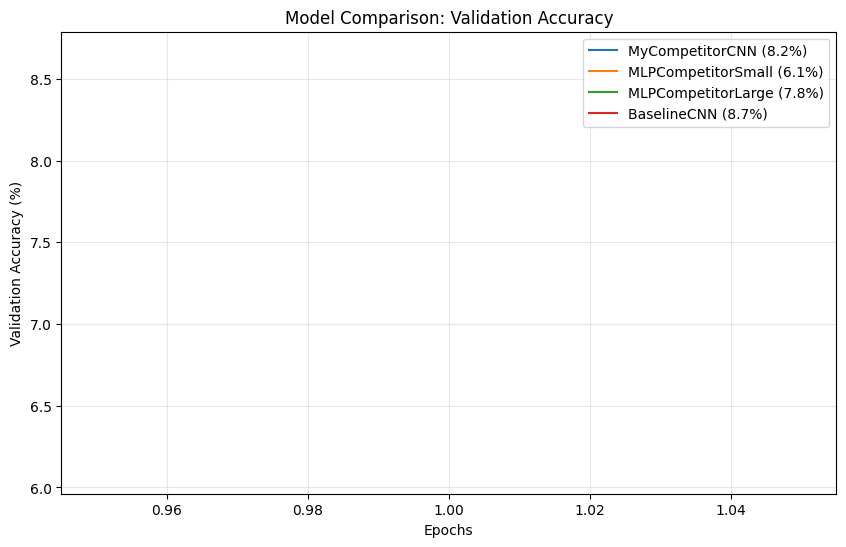


🏅 LEADERBOARD:


,Model,Best Val Acc
3,BaselineCNN,8.66
0,MyCompetitorCNN,8.25
2,MLPCompetitorLarge,7.85
1,MLPCompetitorSmall,6.09


In [24]:
def show_leaderboard():
    log_files = glob.glob("models/*/log.csv")
    results = []
    
    plt.figure(figsize=(10, 6))
    for log_file in log_files:
        folder_name = os.path.dirname(log_file)
        # Extract model name safely by splitting before timestamp (assumes year 202x)
        model_name = os.path.basename(folder_name).split('_20')[0]
        
        df = pd.read_csv(log_file)
        best_acc = df['val_acc'].max()
        
        results.append({
            "Model": model_name,
            "Folder": folder_name,
            "Best Val Acc": best_acc
        })
        plt.plot(df['epoch'], df['val_acc'], label=f"{model_name} ({best_acc:.1f}%)")
        
    plt.title("Model Comparison: Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Validation Accuracy (%)")
    plt.legend(); plt.grid(True, alpha=0.3); plt.show()
    
    if not results:
        print("No models found. Please train models first.")
        return pd.DataFrame()
        
    leaderboard_df = pd.DataFrame(results).sort_values(by="Best Val Acc", ascending=False)
    print("\n🏅 LEADERBOARD:")
    display(leaderboard_df[['Model', 'Best Val Acc']])
    return leaderboard_df

leaderboard = show_leaderboard()

## 7. The Stress Tests 💥

We will test the models in two ways to see if they truly learned the features, or if they just memorized locations.

### Test A: Corner Robustness
Shrinks the image and places it in the corners of the canvas.


🧪 RUNNING STRESS TEST (Corner Robustness)...


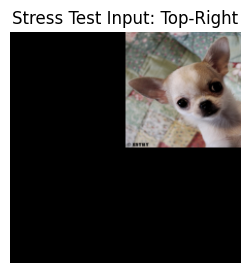


💥 STRESS TEST RESULTS (Corner Robustness):


,Model,Original,Top-Left,Top-Right,Bottom-Left,Bottom-Right,Corner AVG
1,MyCompetitorCNN,7.4,2.8,2.8,3.0,3.4,3.0
0,BaselineCNN,8.5,2.8,2.8,2.8,2.8,2.8
3,MLPCompetitorSmall,6.2,3.1,3.1,1.9,2.7,2.7
2,MLPCompetitorLarge,6.6,2.8,2.6,2.3,1.8,2.4


In [25]:
def run_stress_test(leaderboard_df):
    print("\n🧪 RUNNING STRESS TEST (Corner Robustness)...")
    
    # 1. Prepare Batch (1000 images)
    loader = torch.utils.data.DataLoader(test_set, batch_size=1000, shuffle=False)
    images, labels = next(iter(loader))
    
    # 2. Create Variants
    B, C, H, W = images.shape
    small_h, small_w = 112, 112
    
    # Resize images to 112x112
    small_imgs = F.interpolate(images, size=(small_h, small_w), mode='bilinear', align_corners=False)
    
    variants = {"Original": images}
    corners = {
        "Top-Left":     (0, small_h, 0, small_w),
        "Top-Right":    (0, small_h, W - small_w, W),
        "Bottom-Left":  (H - small_h, H, 0, small_w),
        "Bottom-Right": (H - small_h, H, W - small_w, W),
    }
    
    for name, (y1, y2, x1, x2) in corners.items():
        # Create black canvas (-1.0 in normalized space)
        canvas = torch.full_like(images, -1.0)
        canvas[:, :, y1:y2, x1:x2] = small_imgs
        variants[name] = canvas
        
    # 3. Visualize one example
    ex_img = variants['Top-Right'][0].permute(1, 2, 0) * 0.5 + 0.5
    plt.figure(figsize=(3,3))
    plt.imshow(ex_img)
    plt.title("Stress Test Input: Top-Right")
    plt.axis('off')
    plt.show()

    # 4. Evaluate Models
    stress_results = []
    
    for _, row in leaderboard_df.iterrows():
        model_name = row['Model']
        
        # Dynamic class loading
        if model_name not in globals(): continue
        
        try:
            model = globals()[model_name]().to(device)
            model.load_state_dict(torch.load(f"{row['Folder']}/best_model.pth", map_location=device))
            model.eval()
        except:
            print(f"⚠️ Could not load {model_name}")
            continue
        
        res = {"Model": model_name}
        avg_score = 0
        
        with torch.no_grad():
            for v_name, v_imgs in variants.items():
                v_imgs = v_imgs.to(device)
                outputs = model(v_imgs)
                _, preds = torch.max(outputs, 1)
                
                acc = (preds.cpu() == labels).float().mean().item() * 100
                res[v_name] = round(acc, 1)
                
                if v_name != "Original": # Only count corners for stress score
                    avg_score += acc
        
        res["Corner AVG"] = round(avg_score / 4, 1)
        stress_results.append(res)
        
    # 5. Show Results
    df_stress = pd.DataFrame(stress_results).sort_values(by="Corner AVG", ascending=False)
    print("\n💥 STRESS TEST RESULTS (Corner Robustness):")
    display(df_stress)

if not leaderboard.empty:
    run_stress_test(leaderboard)

### Test B: Translation Robustness (Small Shifts)
What if we don't shrink the image, but simply shift it by 54 pixels to the left, right, up, or down?
This simulates a slightly badly centered camera. Let's see if the CNN survives.


🧪 RUNNING TRANSLATION STRESS TEST (Small Shifts)...


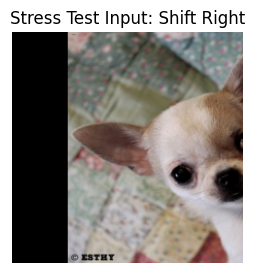


💥 TRANSLATION STRESS TEST RESULTS (Small Shifts):


,Model,Original,Shift Right,Shift Left,Shift Down,Shift Up,Shift AVG
0,BaselineCNN,8.5,6.4,4.5,4.7,5.4,5.2
3,MLPCompetitorSmall,6.2,4.1,2.8,6.4,5.0,4.6
1,MyCompetitorCNN,7.4,4.6,3.8,3.9,5.5,4.5
2,MLPCompetitorLarge,6.6,4.1,3.7,4.7,3.5,4.0


In [26]:
def run_translation_stress_test(leaderboard_df):
    print("\n🧪 RUNNING TRANSLATION STRESS TEST (Small Shifts)...")
    
    # 1. Prepare Batch (1000 images)
    loader = torch.utils.data.DataLoader(test_set, batch_size=1000, shuffle=False)
    images, labels = next(iter(loader))
    
    # 2. Create Variants using torch.roll and masking wrapped pixels
    variants = {"Original": images}
    shift = 54 # Shift by 54 pixels
    
    # Shift Right
    v_right = torch.roll(images, shifts=shift, dims=3)
    v_right[:, :, :, :shift] = -1.0 # Black out wrapped pixels
    variants["Shift Right"] = v_right
    
    # Shift Left
    v_left = torch.roll(images, shifts=-shift, dims=3)
    v_left[:, :, :, -shift:] = -1.0
    variants["Shift Left"] = v_left
    
    # Shift Down
    v_down = torch.roll(images, shifts=shift, dims=2)
    v_down[:, :, :shift, :] = -1.0
    variants["Shift Down"] = v_down
    
    # Shift Up
    v_up = torch.roll(images, shifts=-shift, dims=2)
    v_up[:, :, -shift:, :] = -1.0
    variants["Shift Up"] = v_up
    
    # 3. Visualize one example
    ex_img = variants['Shift Right'][0].permute(1, 2, 0) * 0.5 + 0.5
    plt.figure(figsize=(3,3))
    plt.imshow(ex_img)
    plt.title("Stress Test Input: Shift Right")
    plt.axis('off')
    plt.show()

    # 4. Evaluate Models
    stress_results = []
    
    for _, row in leaderboard_df.iterrows():
        model_name = row['Model']
        
        if model_name not in globals(): continue
        
        try:
            model = globals()[model_name]().to(device)
            model.load_state_dict(torch.load(f"{row['Folder']}/best_model.pth", map_location=device))
            model.eval()
        except:
            print(f"⚠️ Could not load {model_name}")
            continue
        
        res = {"Model": model_name}
        avg_score = 0
        
        with torch.no_grad():
            for v_name, v_imgs in variants.items():
                v_imgs = v_imgs.to(device)
                outputs = model(v_imgs)
                _, preds = torch.max(outputs, 1)
                
                acc = (preds.cpu() == labels).float().mean().item() * 100
                res[v_name] = round(acc, 1)
                
                if v_name != "Original": # Count average of shifted images
                    avg_score += acc
        
        res["Shift AVG"] = round(avg_score / 4, 1)
        stress_results.append(res)
        
    # 5. Show Results
    df_stress = pd.DataFrame(stress_results).sort_values(by="Shift AVG", ascending=False)
    print("\n💥 TRANSLATION STRESS TEST RESULTS (Small Shifts):")
    display(df_stress)

if not leaderboard.empty:
    run_translation_stress_test(leaderboard)